In [ ]:
pip install ultralytics

Now that `ultralytics` is installed, we can proceed with downloading a dataset and then building and training our YOLO model.

In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8n model
model = YOLO('yolov8n.pt')  # You can choose other models like 'yolov8s.pt', 'yolov8m.pt', etc.

# Train the model on a custom dataset
# Replace 'coco8.yaml' with your dataset configuration file
# This file defines the paths to your training and validation images/labels and class names.
# You can create your own .yaml file or use one of the built-in datasets.
results = model.train(data='coco8.yaml', epochs=5, imgsz=640)

print("Training complete! Results are saved in runs/detect/train/")

This code snippet demonstrates loading a `yolov8n` model and initiating its training on a dataset specified by `coco8.yaml`. You will need to replace `coco8.yaml` with your own dataset's YAML configuration file, which should define the paths to your training and validation images, labels, and class names. If you don't have a dataset ready, you can start by exploring the `ultralytics` documentation for information on preparing datasets or using their example datasets.

In [4]:
import os

# List the contents of the training run directory
run_dir = '/content/runs/detect/train'
print(f"Contents of {run_dir}:")
for item in os.listdir(run_dir):
    print(item)

Contents of /content/runs/detect/train:
confusion_matrix.png
train_batch90.jpg
BoxPR_curve.png
BoxF1_curve.png
results.png
BoxR_curve.png
weights
results.csv
confusion_matrix_normalized.png
train_batch0.jpg
val_batch0_pred.jpg
labels.jpg
train_batch91.jpg
train_batch1.jpg
args.yaml
BoxP_curve.png
train_batch92.jpg
val_batch0_labels.jpg
train_batch2.jpg


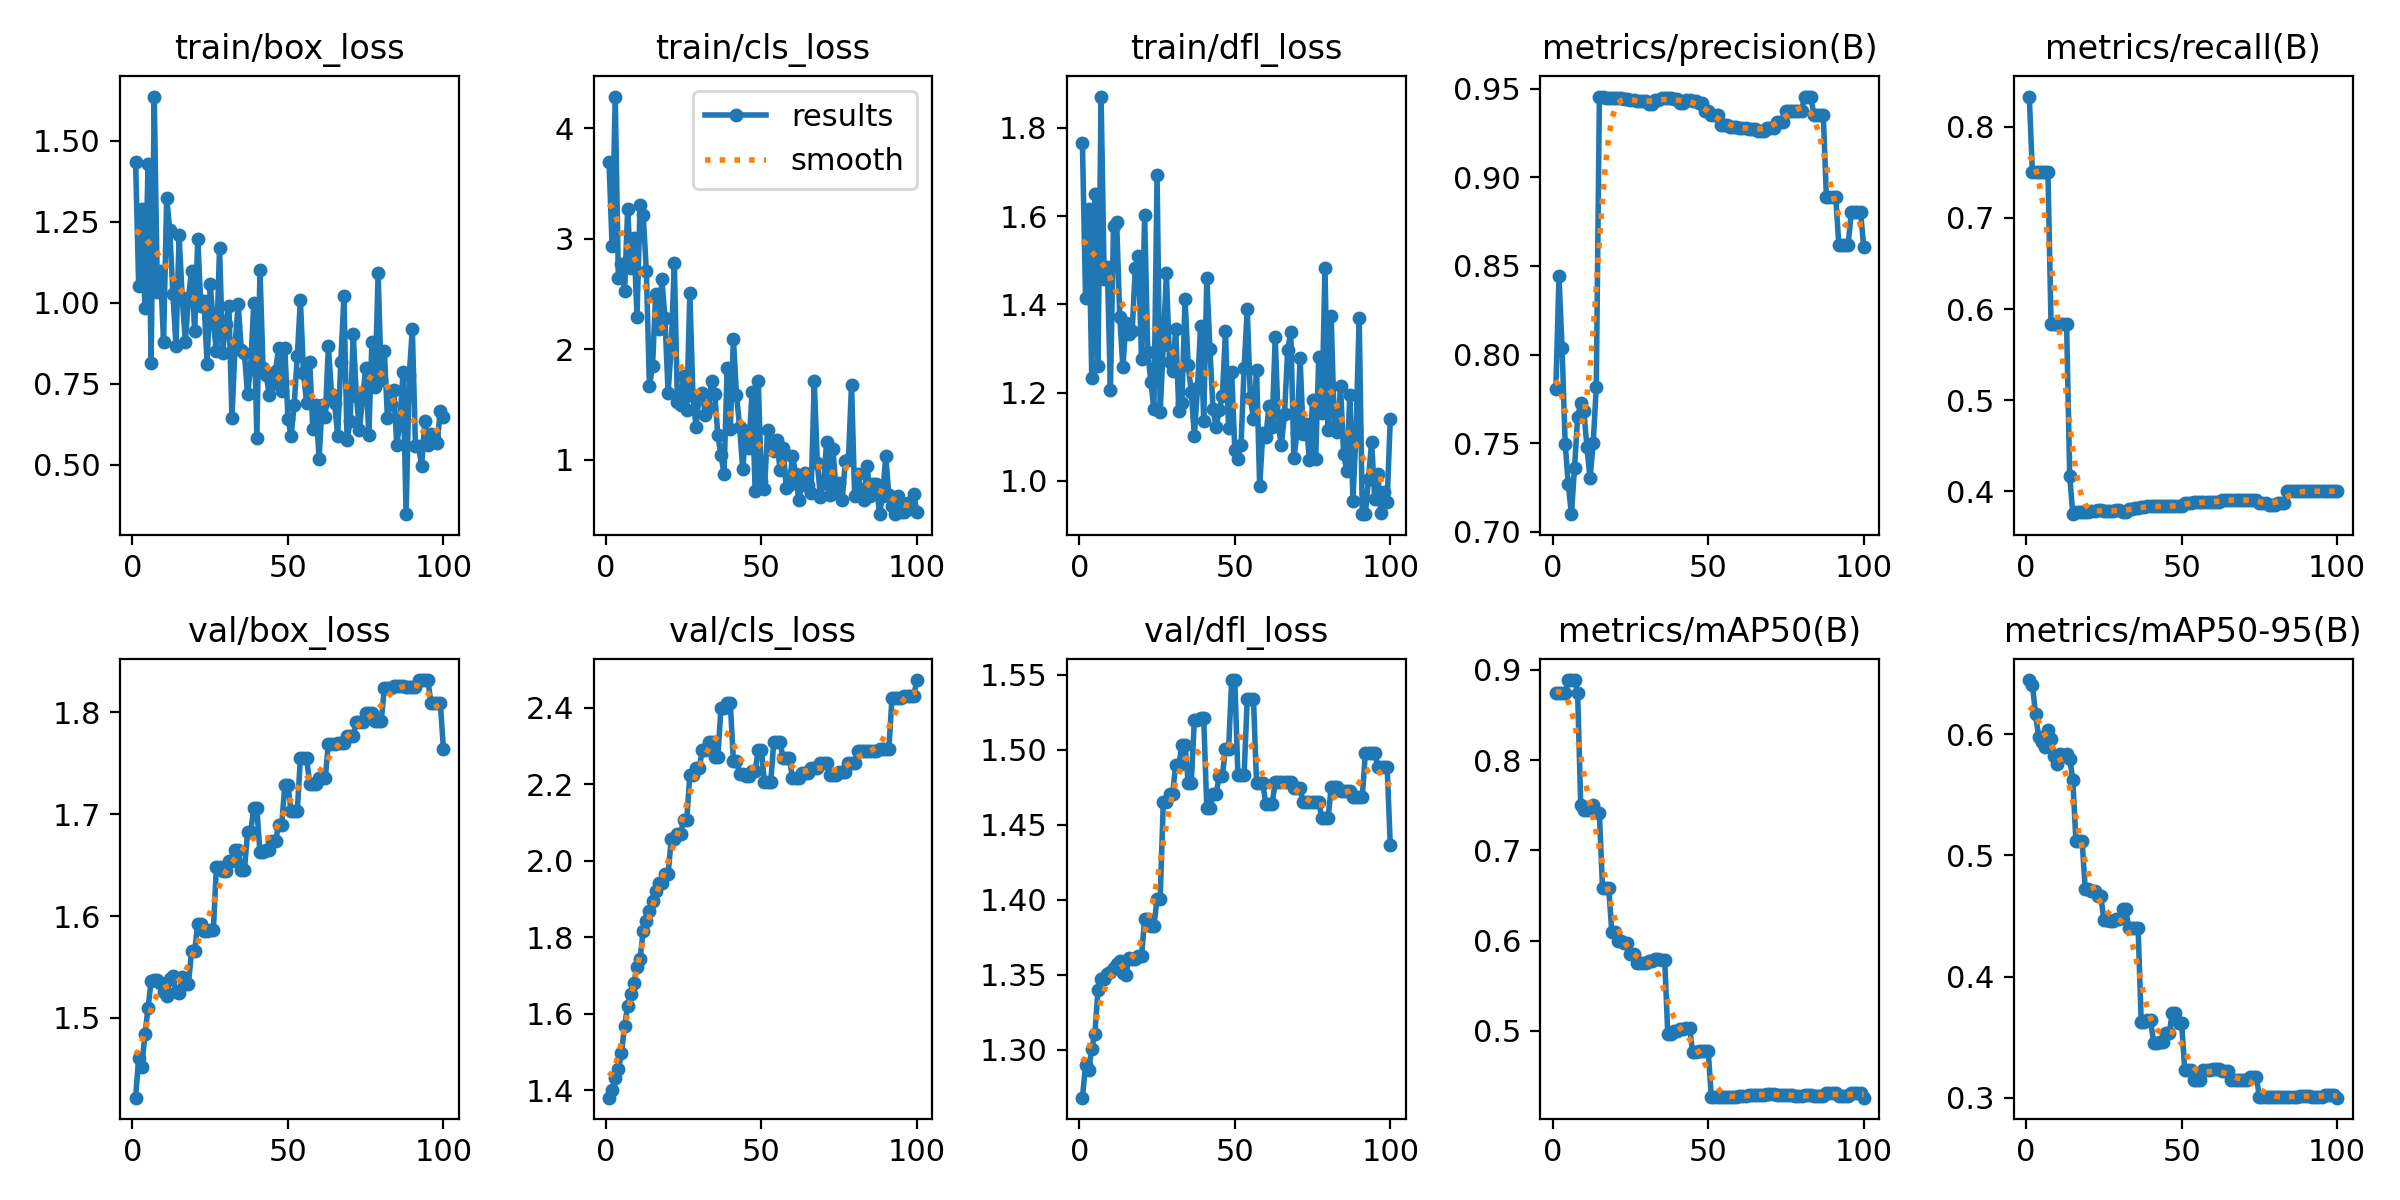

In [5]:
from IPython.display import Image

# Display the main results plot
results_plot_path = os.path.join('/content/runs/detect/train', 'results.png')
if os.path.exists(results_plot_path):
    display(Image(filename=results_plot_path))
else:
    print(f"Results plot not found at {results_plot_path}")


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 175.1ms
Speed: 4.4ms preprocess, 175.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
Predicted image saved to: /content/runs/detect/predict/bus.jpg


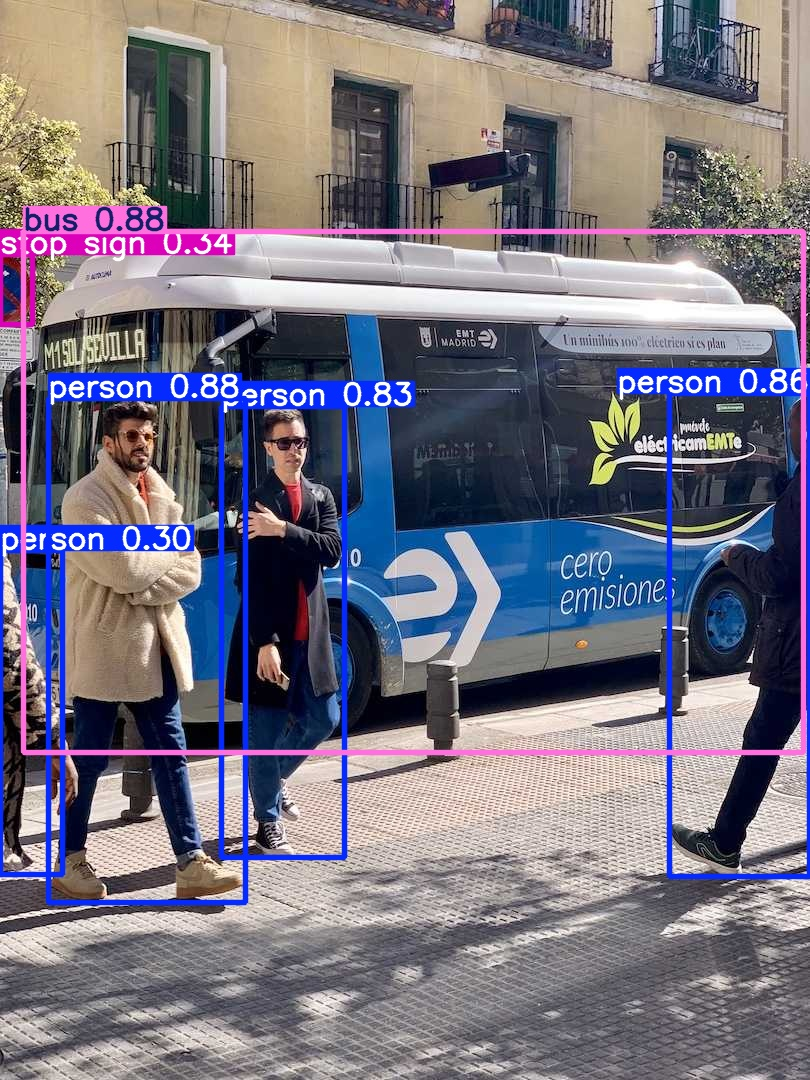

In [6]:
from ultralytics import YOLO
from IPython.display import Image, display

# Load the best trained model weights
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Perform inference on an image
# You can replace this URL with a local image path or a video file
# Example image URL from Ultralytics docs
source_image = 'https://ultralytics.com/images/bus.jpg'

# Run inference
results = model.predict(source=source_image, save=True, conf=0.25)

# Display the predicted image
# The results are saved in a 'predict' folder, usually 'runs/detect/predict'
# We need to find the path to the saved image.
predicted_image_path = results[0].save_dir + '/' + source_image.split('/')[-1]
print(f"Predicted image saved to: {predicted_image_path}")
if os.path.exists(predicted_image_path):
    display(Image(filename=predicted_image_path))
else:
    print("Could not find the predicted image to display.")

The code above loads the `best.pt` weights, which represent the best performing model from our training run. It then uses this model to run predictions on a sample image. The `save=True` argument ensures the image with detected objects and bounding boxes is saved to a `predict` directory (e.g., `runs/detect/predict`). Finally, it displays the image with the predictions.

```yaml
# my_custom_dataset.yaml

# Define the root directory of your dataset
# This path is where your 'images' and 'labels' folders are located.
# For example, if your structure is: my_dataset/images/... and my_dataset/labels/...
# then 'path' would be 'my_dataset/' or '../my_dataset/' if this YAML is in a parent directory.
path: ../datasets/my_custom_dataset/ # Adjust this to your actual dataset root directory

# Define the relative paths to your training and validation image directories
# These paths are relative to the 'path' defined above.
train: images/train  # Path to training images
val: images/val      # Path to validation images
# test: images/test  # Optional: Path to test images (uncomment if you have a test set)

# Define the number of classes (nc) and their names
# The order of names must match the class_id integers (0, 1, 2, ...)
nc: 2 # Example: 2 classes (adjust this to your actual number of classes)
names: ['object_name_1', 'object_name_2']  # Example class names (replace with your object names)
# Example with more classes:
# names: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck']

# Optionally, you can add descriptions or other metadata
# version: 1.0
# description: "My first custom YOLO dataset for object detection."
```

**How to use this:**

1.  **Save this content** into a file named `my_custom_dataset.yaml` (or any `.yaml` name you prefer) in a location accessible by your Colab environment, ideally in your dataset's root directory.
2.  **Ensure your dataset directory structure matches** the `path`, `train`, `val` (and `test`) definitions.
3.  **Update `nc`** with the total number of unique object classes you have.
4.  **List your object `names`** in the exact order corresponding to the `class_id` integers (0, 1, 2, ...) used in your annotation `.txt` files.

Once this YAML file is ready, you can pass it to the `model.train()` function like this:

`results = model.train(data='path/to/my_custom_dataset.yaml', epochs=100, imgsz=640)`